# 2. Bias Analysis

This notebook assesses **fairness** of NovaCred's credit decisions: disparate impact by gender, proxy discrimination, and age-based patterns. Uses the **cleaned** dataset from `01-data-quality.ipynb`.

**Owner:** Data Scientist (refine and extend as needed).

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: pip install fairlearn
# from fairlearn.metrics import demographic_parity_difference

DATA_PATH = Path("../data/credit_applications_clean_final.csv")

In [32]:
df = pd.read_csv(DATA_PATH)
df["applicant_info.date_of_birth"] = pd.to_datetime(df["applicant_info.date_of_birth"], errors="coerce")
print("Shape:", df.shape)
df.head(3)

Shape: (498, 22)


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes,_missing_critical_financials
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15 00:00:00+00:00,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,...,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,0
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,...,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,0
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,...,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN,0


## 2.1 Disparate impact by gender (four-fifths rule)

**DI = (approval rate of unprivileged group) / (approval rate of privileged group)**  
A value **below 0.8** indicates potential disparate impact.

In [33]:
gender_col = "applicant_info.gender"
outcome_col = "decision.loan_approved"

valid = df[df[gender_col].isin(["Male", "Female"])].copy()
rates = valid.groupby(gender_col)[outcome_col].agg(["mean", "sum", "count"])
rates.columns = ["approval_rate", "approved", "total"]
display(rates)

# Privileged = Male, Unprivileged = Female (typical convention for credit; adjust if needed)
rate_privileged = rates.loc["Male", "approval_rate"]
rate_unprivileged = rates.loc["Female", "approval_rate"]
di_ratio = rate_unprivileged / rate_privileged if rate_privileged > 0 else float("nan")

print(f"\nApproval rate (Male):   {rate_privileged:.2%}")
print(f"Approval rate (Female): {rate_unprivileged:.2%}")
print(f"Disparate impact ratio: {di_ratio:.3f}")
print(f"Four-fifths rule (DI < 0.8): {'Potential disparate impact' if di_ratio < 0.8 else 'Within threshold'}")

,approval_rate,approved,total
applicant_info.gender,,,
Female,0.508000,127,250
Male,0.662602,163,246



Approval rate (Male):   66.26%
Approval rate (Female): 50.80%
Disparate impact ratio: 0.767
Four-fifths rule (DI < 0.8): Potential disparate impact


**Statistical test:** Chi-square test for independence (gender vs approval). A low p-value suggests the association is unlikely due to chance.

In [34]:
# Chi-square test for independence: gender vs approval
from scipy.stats import chi2_contingency
cont_table = pd.crosstab(valid[gender_col], valid[outcome_col])
chi2, p_value, dof, expected = chi2_contingency(cont_table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Conclusion: {'Association is statistically significant (reject independence)' if p_value < 0.05 else 'Cannot reject independence at 5% level'}")

Chi-square statistic: 11.5761
p-value: 0.0007
Conclusion: Association is statistically significant (reject independence)


**Interpretation (2.1)**  
The disparate impact ratio of about 0.77 is below the 0.8 threshold, indicating **potential disparate impact** on female applicants: their approval rate is meaningfully lower than males’ (about 51% vs 66%). If the chi-square test yields a low p-value, the association between gender and approval is unlikely due to chance. The team should flag this for governance and consider model or data remediation (e.g. fairness constraints, feature review, or further analysis of drivers).

## 2.2 Proxy discrimination

Check whether non-protected attributes (e.g. zip, income) correlate with protected ones (gender) and with outcomes.

In [35]:
# Approval rate by zip_code (geography as potential proxy)
zip_col = "applicant_info.zip_code"
by_zip = df.groupby(zip_col).agg(
    approval_rate=(outcome_col, "mean"),
    count=(outcome_col, "count"),
    pct_female=(gender_col, lambda s: (s == "Female").mean())
).round(3)
by_zip = by_zip[by_zip["count"] >= 10].sort_values("approval_rate")
display(by_zip.head(10))
if len(by_zip) == 0:
    print("No zip code has ≥10 applicants — exact-zip analysis is empty (data too sparse).")
    print("Using zip code prefix (first 3 digits) to group into regions:")
    df_zip = df[df[zip_col].notna()].copy()
    df_zip["zip_prefix"] = df_zip[zip_col].astype(int).astype(str).str[:3]
    by_region = df_zip.groupby("zip_prefix").agg(
        approval_rate=(outcome_col, "mean"),
        count=(outcome_col, "count"),
        pct_female=(gender_col, lambda s: (s == "Female").mean())
    ).round(3)
    by_region = by_region[by_region["count"] >= 5].sort_values("approval_rate")
    display(by_region)
    print("If approval_rate and pct_female move together across regions, geography may act as a proxy for gender.")
else:
    print("\nIf approval_rate and pct_female move together, zip may act as a proxy for gender.")

,approval_rate,count,pct_female
applicant_info.zip_code,,,



If approval_rate and pct_female move together, zip may act as a proxy for gender.


**Debt-to-income (DTI) by gender:** If average DTI is similar but approval rates differ, the model may be using the same input differently by group.

In [36]:
dti_col = "financials.debt_to_income"
dti_valid = valid[[gender_col, dti_col, outcome_col]].dropna()
for g in ["Male", "Female"]:
    sub = dti_valid[dti_valid[gender_col] == g]
    print(f"{g}: mean DTI = {sub[dti_col].mean():.3f}, approval rate = {sub[outcome_col].mean():.2%}, n = {len(sub)}")

Male: mean DTI = 0.248, approval rate = 66.26%, n = 246
Female: mean DTI = 0.244, approval rate = 50.80%, n = 250


In [37]:
# Correlation: income vs approval, by gender
inc_col = "financials.annual_income"
sub = valid[[gender_col, inc_col, outcome_col]].dropna()
for g in ["Male", "Female"]:
    r = sub.loc[sub[gender_col] == g, [inc_col, outcome_col]].corr().iloc[0, 1]
    print(f"Corr(income, approved) for {g}: {r:.3f}")

Corr(income, approved) for Male: 0.138
Corr(income, approved) for Female: 0.249


**Rejection reason by gender:** If one group is more often rejected for a given reason (e.g. `algorithm_risk_score`), that can signal bias in the model or data.

In [38]:
rej_col = "decision.rejection_reason"
rej_valid = valid[valid[rej_col].notna()]
if len(rej_valid) > 0:
    rej_by_gender = pd.crosstab(rej_valid[gender_col], rej_valid[rej_col], normalize="index").round(3)
    display(rej_by_gender)
    print("Rows = gender, columns = rejection reason (share of rejected applicants in that group).")
else:
    print("No rejection reasons in cleaned data for this subset.")

decision.rejection_reason,algorithm_risk_score,high_dti_ratio,insufficient_credit_history,low_income
applicant_info.gender,,,,
Female,0.805,0.065,0.122,0.008
Male,0.819,0.048,0.096,0.036


Rows = gender, columns = rejection reason (share of rejected applicants in that group).


**Interpretation (2.2)**  
No single zip code has ≥10 applicants, so exact-zip analysis is empty (data too sparse). The notebook therefore groups by zip prefix (first 3 digits) to get regions; if the region table shows approval_rate and pct_female moving together, geography could act as a proxy for gender. Mean DTI is similar for males and females yet approval differs—suggesting the model may use the same inputs differently by group. Income correlates more strongly with approval for females; rejection reasons are similar across gender. Treat the DTI/approval gap as a signal for further investigation and monitor rejection reasons as more data becomes available.

## 2.3 Age-based patterns

Derive age from date of birth and check approval rates by age group.

In [39]:
ref_date = pd.Timestamp("2024-01-01")
df["age"] = ((ref_date - df["applicant_info.date_of_birth"]).dt.days / 365.25).astype(float)
age_valid = df[df["age"].between(18, 100)].copy()
age_valid["age_group"] = pd.cut(age_valid["age"], bins=[18, 30, 40, 50, 65, 100], labels=["18-30", "31-40", "41-50", "51-65", "65+"])
by_age = age_valid.groupby("age_group")[outcome_col].agg(["mean", "count"]).round(3)
by_age.columns = ["approval_rate", "count"]
display(by_age)
print("\nConsider whether approval rates differ materially across age groups (age-based bias).")

,approval_rate,count
age_group,,
18-30,0.414,116
31-40,0.625,168
41-50,0.688,125
51-65,0.573,82
65+,1.000,3



Consider whether approval rates differ materially across age groups (age-based bias).


**Interpretation (2.3)**  
Approval rates vary by age: lowest for 18–30 (about 41%), higher for 31–40 and 41–50 (about 63–69%), and lower again for 51–65 (about 57%). The 65+ group has very few applicants. This pattern suggests age may be associated with outcomes; the team should confirm whether this reflects risk-relevant factors (e.g. income, tenure) or possible age-related bias, and document the rationale for any age-related policy.

## 2.4 Visualizations

Add plots for the video and README (e.g. bar chart of approval by gender, by age group).

### 2.3.1 Interaction: gender × age

Approval rate by both gender and age group. Large differences within an age band suggest interaction effects.

approval_rate         count     
applicant_info.gender        Female   Male Female Male
age_group                                             
18-30                         0.311  0.527     61   55
31-40                         0.580  0.667     81   87
41-50                         0.600  0.769     60   65
51-65                         0.511  0.639     45   36
65+                           1.000  1.000      1    2

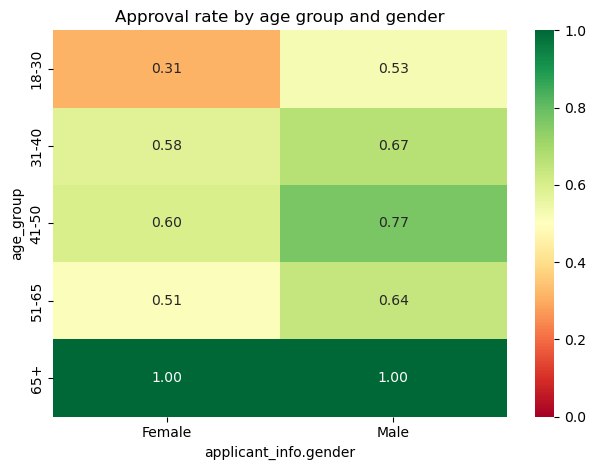

In [40]:
# Approval rate by gender and age group
age_valid_g = age_valid[age_valid[gender_col].isin(["Male", "Female"])]
by_gender_age = age_valid_g.groupby([gender_col, "age_group"])[outcome_col].agg(["mean", "count"]).round(3)
by_gender_age.columns = ["approval_rate", "count"]
display(by_gender_age.unstack(level=0))
# Pivot for a heatmap
pivot = age_valid_g.pivot_table(values=outcome_col, index="age_group", columns=gender_col, aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1)
plt.title("Approval rate by age group and gender")
plt.tight_layout()
plt.show()

**Interpretation (2.3.1)**  
Female approval is lower than male in every age band; the gap is largest for 18–30 (about 31% vs 53%). The heatmap and table make this interaction easy to communicate. The combination of gender and age suggests that young women are particularly affected; the team should prioritize this segment for fairness review and consider segment-specific analyses or mitigations.

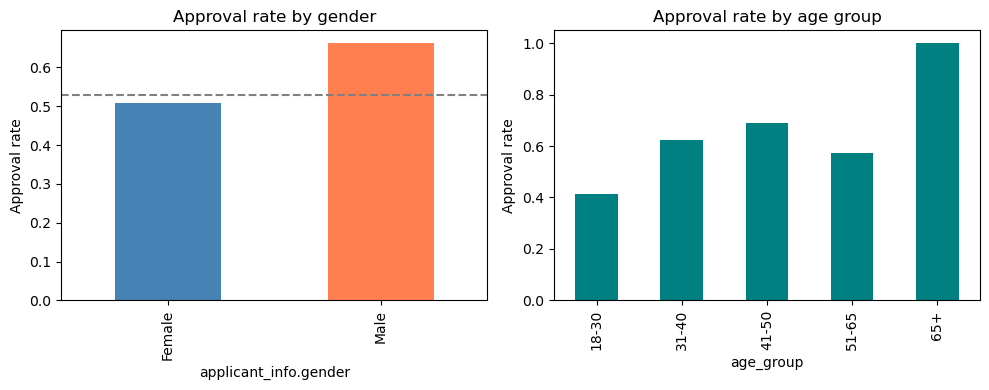

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

rates.plot(kind="bar", y="approval_rate", ax=axes[0], color=["steelblue", "coral"], legend=False)
axes[0].set_title("Approval rate by gender")
axes[0].set_ylabel("Approval rate")
axes[0].axhline(0.8 * rate_privileged, color="gray", linestyle="--", label="4/5 of Male rate")

by_age["approval_rate"].plot(kind="bar", ax=axes[1], color="teal", legend=False)
axes[1].set_title("Approval rate by age group")
axes[1].set_ylabel("Approval rate")

plt.tight_layout()
plt.show()

## 2.5 Summary

- **Disparate impact (gender):** DI ratio and interpretation vs four-fifths rule; chi-square test for statistical significance.
- **Proxy discrimination:** Zip (approval + % female), income vs approval by gender, DTI by gender, rejection reason by gender.
- **Age:** Approval by age group; interaction (gender × age) with heatmap.
- **Visualizations:** Approval by gender, by age group, and heatmap by gender × age. Add fairlearn or further tests as needed.

**Interpretation (2.4)**  
The bar charts and heatmap summarize approval by gender, by age group, and by gender×age. They are suitable for the README and video to show where disparities appear and to support governance discussions with clear visuals.

**Overall interpretation**  
The analysis indicates potential disparate impact by gender (DI &lt; 0.8) and a consistent gender gap across age groups, with the largest gap for 18–30. Proxy and rejection-reason checks do not clearly explain the gap; DTI is similar by gender while approval differs. Recommended next steps: (1) present these findings to governance and product, (2) deepen analysis of drivers (e.g. features, segments, model logic), and (3) consider fairness mitigations and ongoing monitoring as part of the data ecosystem governance.